# Experiment 02 - Contour Alchemy

## Forschungsfrage

Welche neuen Strukturen entstehen durch Bin Stretch Art?

Können diese Strukturen durch Konturverfahren isoliert und sichtbar gemacht werden?

---

## Ausgangspunkt

Experiment 01 zeigte:

- neue Himmelsstrukturen
- Texturen in Kleidung
- neue Muster in Haaren
- zusätzliche Konturen

---

## Hypothese

Bin Stretch erzeugt neue lokale Intensitätsunterschiede.

Diese sollten durch Konturdetektoren sichtbar gemacht werden können.

---

## Ziel

Vergleich:

Originalbild

↓

Bin Stretch

↓

Konturen

In [1]:
# ============================================================
# ZELLE 1
# Imports
# ============================================================

from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt

from PIL import Image

In [2]:
# ============================================================
# ZELLE 2
# Projektpfade
# ============================================================

PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"

OUTPUT_DIR = PROJECT_ROOT / "data" / "output"

print(PROJECT_ROOT)
print(RAW_DIR)
print(OUTPUT_DIR)

c:\_AA-LapTop-MSIT\_MyPixelAlchemy
c:\_AA-LapTop-MSIT\_MyPixelAlchemy\data\raw
c:\_AA-LapTop-MSIT\_MyPixelAlchemy\data\output


In [10]:
# ============================================================
# ZELLE 3A
# EXIF Orientierung automatisch korrigieren
# ============================================================

from PIL import ImageOps

image = Image.open(image_path)

image = ImageOps.exif_transpose(
    image
)

image_array = np.array(image)

print(image_array.shape)

(3408, 2556, 3)


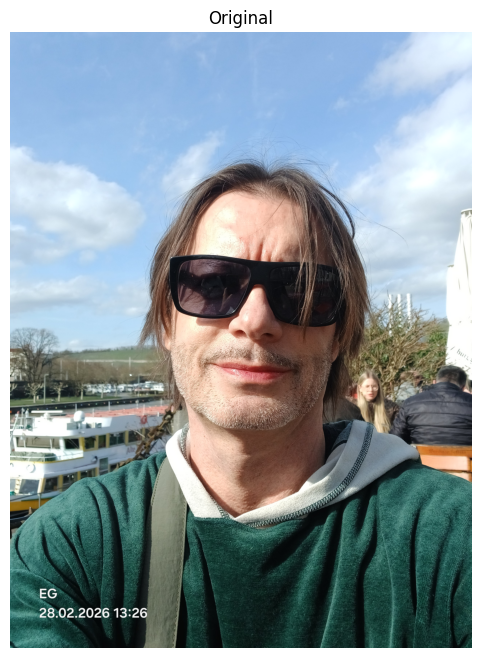

In [12]:
# ============================================================
# ZELLE 4
# Originalbild anzeigen
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(image_array)

plt.axis("off")

plt.title("Original")

plt.show()

In [13]:
# ============================================================
# ZELLE 5
# Bin Stretch Funktion
# ============================================================

def bin_stretch_channel(
    channel: np.ndarray,
    n_bins: int,
) -> np.ndarray:

    bin_width = 256 / n_bins

    result = np.zeros_like(
        channel,
        dtype=np.float32,
    )

    for bin_index in range(n_bins):

        lower = bin_index * bin_width

        upper = (bin_index + 1) * bin_width

        mask = (
            (channel >= lower)
            &
            (channel < upper)
        )

        result[mask] = (
            (channel[mask] - lower)
            / bin_width
        ) * 255

    return result.astype(np.uint8)

In [14]:
# ============================================================
# ZELLE 6
# RGB Bin Stretch
# ============================================================

def transform_rgb_image(
    image_array: np.ndarray,
    n_bins: int,
) -> np.ndarray:

    red = image_array[:, :, 0]

    green = image_array[:, :, 1]

    blue = image_array[:, :, 2]

    red_new = bin_stretch_channel(
        red,
        n_bins,
    )

    green_new = bin_stretch_channel(
        green,
        n_bins,
    )

    blue_new = bin_stretch_channel(
        blue,
        n_bins,
    )

    return np.stack(
        [
            red_new,
            green_new,
            blue_new,
        ],
        axis=2,
    )

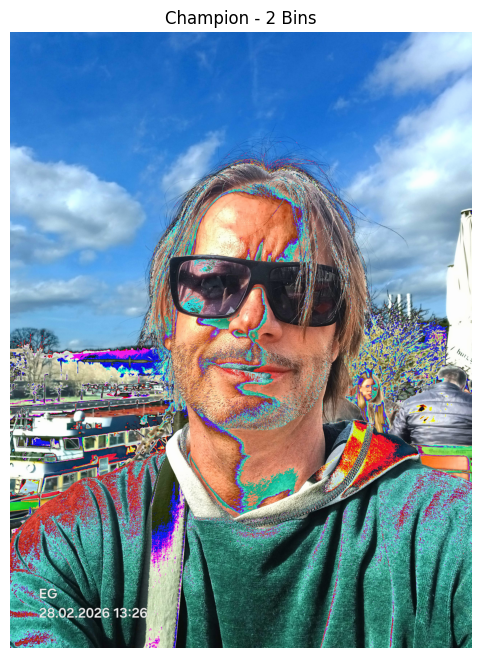

In [15]:
# ============================================================
# ZELLE 7
# Champion
# ============================================================

champion_image = transform_rgb_image(
    image_array=image_array,
    n_bins=2,
)

plt.figure(figsize=(8, 8))

plt.imshow(champion_image)

plt.axis("off")

plt.title("Champion - 2 Bins")

plt.show()

(3408, 2556)


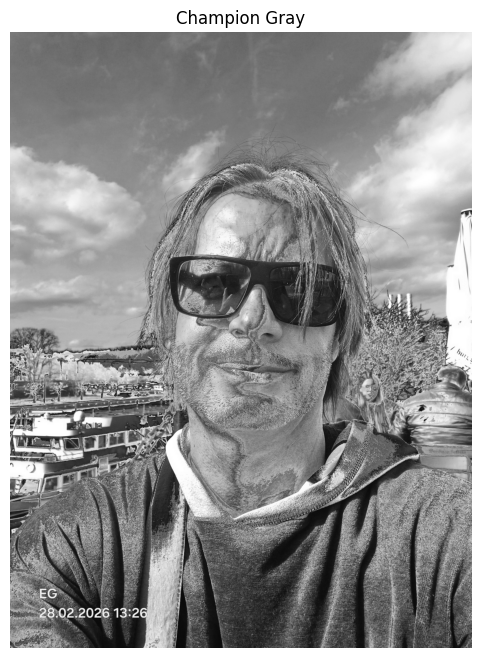

In [16]:
# ============================================================
# ZELLE 8
# Champion in Graustufen umwandeln
# ============================================================

champion_gray = np.mean(
    champion_image,
    axis=2
).astype(np.uint8)

print(champion_gray.shape)

plt.figure(figsize=(8, 8))

plt.imshow(
    champion_gray,
    cmap="gray"
)

plt.axis("off")

plt.title("Champion Gray")

plt.show()

(3408, 2555)


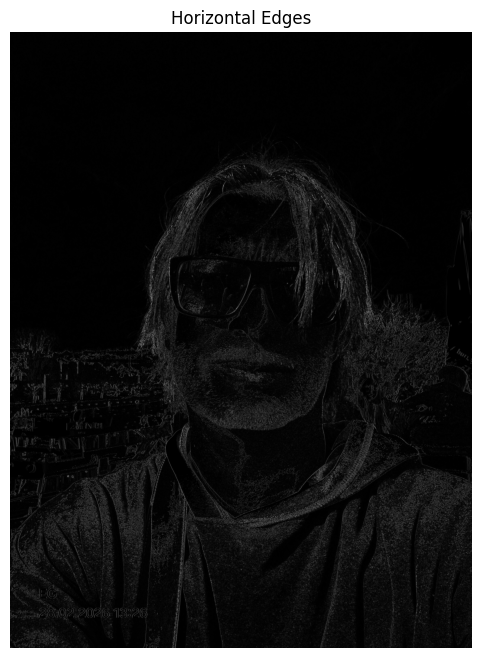

In [17]:
# ============================================================
# ZELLE 9
# Horizontale Intensitätsänderungen
# ============================================================

edge_horizontal = np.abs(
    np.diff(
        champion_gray.astype(np.int16),
        axis=1
    )
)

print(edge_horizontal.shape)

plt.figure(figsize=(8, 8))

plt.imshow(
    edge_horizontal,
    cmap="gray"
)

plt.axis("off")

plt.title("Horizontal Edges")

plt.show()

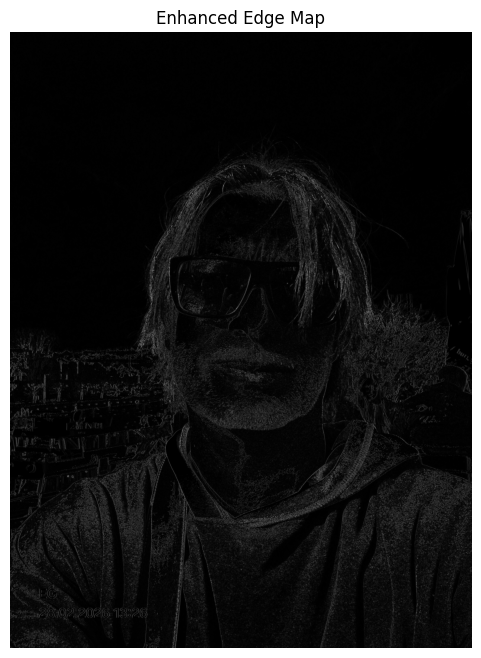

In [18]:
# ============================================================
# ZELLE 10
# Kantenbild strecken
# ============================================================

edge_display = (
    edge_horizontal
    /
    edge_horizontal.max()
    * 255
).astype(np.uint8)

plt.figure(figsize=(8, 8))

plt.imshow(
    edge_display,
    cmap="gray"
)

plt.axis("off")

plt.title("Enhanced Edge Map")

plt.show()

(3407, 2556)


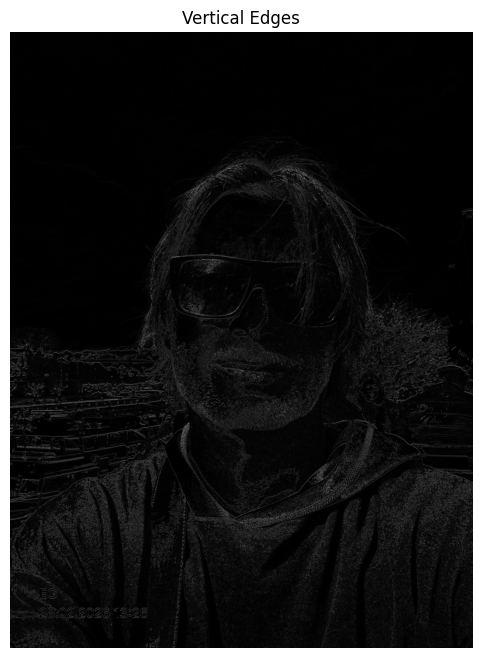

In [19]:
# ============================================================
# ZELLE 11
# Vertikale Intensitätsänderungen
# ============================================================

edge_vertical = np.abs(
    np.diff(
        champion_gray.astype(np.int16),
        axis=0
    )
)

print(edge_vertical.shape)

plt.figure(figsize=(8, 8))

plt.imshow(
    edge_vertical,
    cmap="gray"
)

plt.axis("off")

plt.title("Vertical Edges")

plt.show()

In [20]:
# ============================================================
# ZELLE 12
# Gemeinsame Bildgröße erzeugen
# ============================================================

edge_h = edge_horizontal[:-1, :]

edge_v = edge_vertical[:, :-1]

print(edge_h.shape)
print(edge_v.shape)

(3407, 2555)
(3407, 2555)


In [21]:
# ============================================================
# ZELLE 13
# Horizontale + Vertikale Kanten
# ============================================================

edge_combined = np.sqrt(
    edge_h.astype(np.float32) ** 2
    +
    edge_v.astype(np.float32) ** 2
)

print(edge_combined.shape)

(3407, 2555)


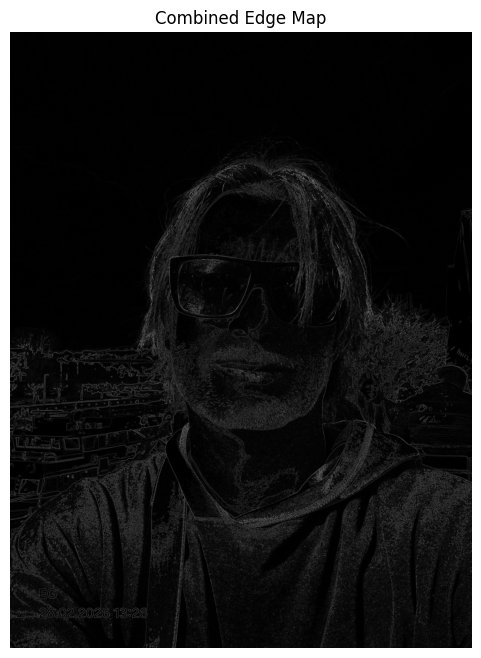

In [22]:
# ============================================================
# ZELLE 14
# Kombinierte Edge Map
# ============================================================

edge_display = (
    edge_combined
    /
    edge_combined.max()
    * 255
).astype(np.uint8)

plt.figure(figsize=(8, 8))

plt.imshow(
    edge_display,
    cmap="gray"
)

plt.axis("off")

plt.title("Combined Edge Map")

plt.show()


In [23]:
# ============================================================
# ZELLE 15
# Schwellenwert
# ============================================================

threshold = 50

edge_binary = (
    edge_display > threshold
).astype(np.uint8)

print(
    "Anteil Kanten:",
    edge_binary.mean()
)

Anteil Kanten: 0.05089429670811274


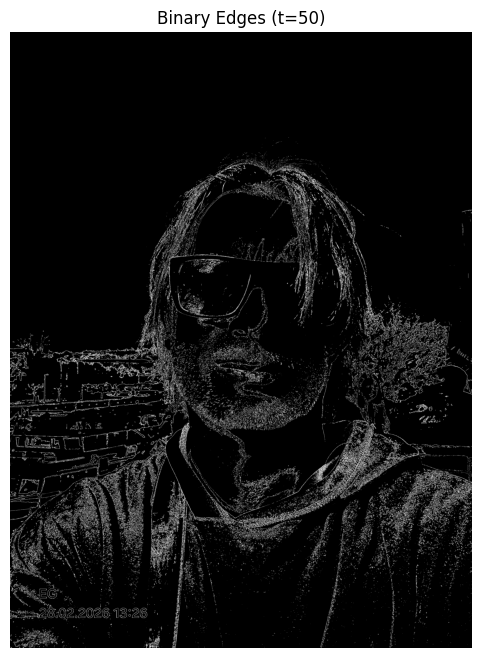

In [24]:
# ============================================================
# ZELLE 16
# Schwarz-Weiß Konturen
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(
    edge_binary,
    cmap="gray"
)

plt.axis("off")

plt.title(
    f"Binary Edges (t={threshold})"
)

plt.show()

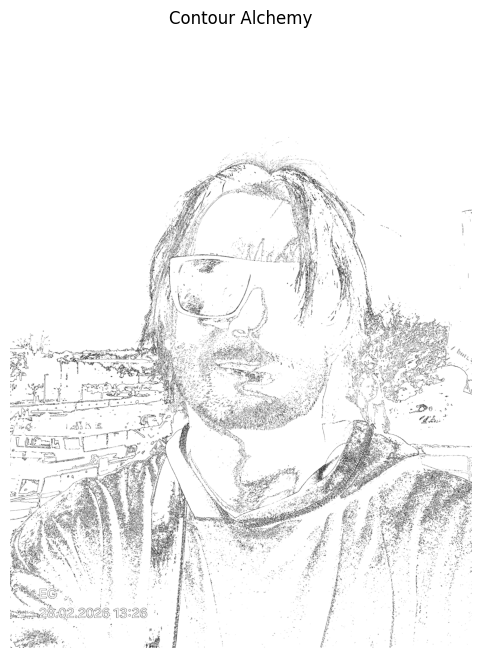

In [25]:
# ============================================================
# ZELLE 17
# Invertierte Konturen
# ============================================================

edge_inverted = (
    1 - edge_binary
)

plt.figure(figsize=(8, 8))

plt.imshow(
    edge_inverted,
    cmap="gray"
)

plt.axis("off")

plt.title(
    "Contour Alchemy"
)

plt.show()

In [26]:
# ============================================================
# ZELLE 18
# Ausgabeordner Experiment 02
# ============================================================

EXP02_DIR = OUTPUT_DIR / "experiment_02"

EXP02_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(EXP02_DIR)

c:\_AA-LapTop-MSIT\_MyPixelAlchemy\data\output\experiment_02


In [29]:
# ============================================================
# ZELLE 19
# Contour Alchemy speichern
# ============================================================

from PIL import Image

output_path = (
    EXP02_DIR
    / "contour_alchemy_v01.jpg"
)

Image.fromarray(
    (edge_inverted * 255).astype(np.uint8)
).save(
    output_path,
    quality=95,
)

print(output_path)

c:\_AA-LapTop-MSIT\_MyPixelAlchemy\data\output\experiment_02\contour_alchemy_v01.jpg


In [30]:
# ============================================================
# ZELLE 20
# Kontrolle
# ============================================================

for file in EXP02_DIR.glob("*.jpg"):

    print(file.name)

contour_alchemy_v01.jpg
